# Laboratorio 2 - Aprendizaje de Máquina

## Miembros del grupo

| Nombre             | Código    | Correo electrónico           |
|--------------------|-----------|------------------------------|
| Adrian Velasquez   | 202222737 | a.velasquezs@uniandes.edu.co |

In [1]:
# Importar paquetes
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler, Normalizer, MaxAbsScaler
from sklearn.utils import resample

# Preparación

La preparación de los datos se hace con base en la limpieza realizada para el laboratorio 1.
> **Nota**: Se hicieron algunas modificaciones menores a la limpieza que no fueron entregadas en el Laboratorio 1, principalmente algunos ajustes a la eliminación de outliers para evitar valores extremos que podrían afectar el entrenamiento de los modelos polinomiales. Sin embargo, la estructura general del dataset se mantiene igual a la entregada en el Laboratorio 1.

In [2]:
# Variables importantes
DATA_DIRNAME = './data/'
CLEAN_DATA = DATA_DIRNAME + 'clean_data.csv'
TEST_DATA = DATA_DIRNAME + 'test.csv'
MODELS_DIRNAME = './models/'
MODEL_FILENAME = MODELS_DIRNAME + 'model.pkl'

In [3]:
# Importar datos limpios del lab pasado
df = pd.read_csv( CLEAN_DATA )
df.head()

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,2020-03-21,F,52.000000,109.700000,1.780,34.623154,104.400,103/99,197.000000,0.915,...,High,N,178.000,0.586517,103,99,Hypertension Stage 2,113.190076,18.010,HIGH
1,2020-03-03,F,46.769697,104.469000,1.995,26.248328,86.894,164/90,198.971213,82.000,...,Low,Y,199.458,0.435559,164,90,Hypertension Stage 2,147.000000,18.458,HIGH
2,2022-03-08,M,58.000000,85.880566,1.870,24.559057,99.600,113/91,106.000000,6.809,...,Low,N,187.000,0.532620,113,91,Hypertension Stage 2,33.000000,16.530,HIGH
3,2025-09-17,F,52.000000,107.800000,1.780,34.023482,103.500,111/69,179.000000,73.000,...,Low,Y,178.000,0.581461,111,69,Normal,76.000000,15.930,HIGH
4,2023-08-13,F,50.000000,99.400000,1.670,35.641292,96.300,144/81,256.000000,30.000,...,Moderate,N,167.000,0.576647,144,81,Hypertension Stage 1,196.000000,19.440,HIGH


In [4]:
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (1166, 23)


In [5]:
# Cambiar a tipo fecha
df['Date of Service'] = pd.to_datetime(df['Date of Service'])
df.sample(5)

,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
72,2023-08-17,M,36.0,106.200000,1.760,34.284607,74.800,124/66,171.0,48.0,...,High,N,176.000000,0.425000,124,66,Elevated,93.0,16.480,INTERMEDIARY
477,2021-08-08,M,44.0,113.000000,1.700,39.100346,82.600,113/70,270.0,44.0,...,High,N,170.000000,0.485882,113,70,Normal,196.0,20.870,HIGH
792,2025-08-04,F,35.0,64.837000,1.958,16.912100,88.896,160/78,152.0,59.0,...,High,Y,195.794000,0.454014,160,78,Hypertension Stage 2,63.0,17.676,HIGH
517,2025-06-29,F,30.0,89.600000,1.780,28.279258,70.100,133/97,239.0,79.0,...,Low,N,175.737219,0.393820,133,97,Hypertension Stage 1,130.0,19.090,HIGH
501,2025-03-04,M,30.0,85.880566,1.830,25.644410,75.100,91/95,277.0,32.0,...,Moderate,Y,183.000000,0.410383,91,95,Hypertension Stage 2,215.0,14.610,HIGH


In [6]:
# Separar variables independientes y dependientes
TARGET = 'CVD Risk Score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [7]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Verificar dimensiones de los conjuntos de entrenamiento
print(f"Valores de entrenamiento X: {X_train.shape}")
print(f"Valores de entrenamiento y: {y_train.shape[0]}")

Valores de entrenamiento X: (932, 22)
Valores de entrenamiento y: 932


In [9]:
# Verificar dimensiones de los conjuntos de prueba
print(f"Valores de test X: {X_test.shape}")
print(f"Valores de test y: {y_test.shape[0]}")

Valores de test X: (234, 22)
Valores de test y: 234


In [10]:
# Identificar columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include=['str']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'datetime']).columns
print(f"Columnas categóricas: {cat_cols}")
print(f"Columnas numéricas: {num_cols}")

Columnas categóricas: Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='str')
Columnas numéricas: Index(['Date of Service', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)'],
      dtype='str')


# Modelo polinomial

Para el modelo polinomial se tendrá en cuenta el `PolynomialFeatures` de `sklearn.preprocessing` para generar características polinomiales a partir de las variables numéricas. Esto permitirá capturar relaciones no lineales entre las variables independientes y la variable dependiente. Se evaluará el rendimiento del modelo polinomial utilizando métricas como el error cuadrático medio (MSE) y el coeficiente de determinación ($R^2$) para comparar con otros modelos lineales y polinomiales regularizados.

## Definir pipeline para modelo polinomial

In [11]:
# Escoger columnas a eliminar de acuerdo al negocio
cols_to_drop = [
    'CVD Risk Level', # Representa una categorización del riesgo, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
    'Date of Service', # No es relevante para el modelo
    'Blood Pressure (mmHg)', # Se puede descomponer en sistólica y diastólica
    # 'Systolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    # 'Diastolic BP', # Está incluido en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Weight (kg)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (cm)', # Se puede descomponer en BMI, por lo que se puede eliminar para evitar multicolinealidad
    'Height (m)', # Se elimina para evitar multicolinealidad con Height (cm) y Weight (kg)
    # 'Estimated LDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    # 'HDL (mg/dL)', # Se puede descomponer en Total Cholesterol, por lo que se puede eliminar para evitar multicolinealidad
    'Blood Pressure Category', # Representa una categorización de la presión arterial, pero el modelo se enfocará en predecir el puntaje de riesgo continuo
    # 'Abdominal Circumference (cm)', # Se decompone en Waist-to-Height Ratio, por lo que se puede eliminar para evitar multicolinealidad
]

In [12]:
# Definir función para eliminar columnas
def drop_columns( xt ):
    return xt.drop(columns=cols_to_drop)

dropper = FunctionTransformer(drop_columns)

In [13]:
# Pipeline para transformar variables numéricas con polinomios
poli_num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ('poly', PolynomialFeatures(degree=2))
    ]
)

In [14]:
# Pipeline para transformar variables categóricas con one-hot encoding y polinomios
poli_cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [15]:
# Adquirir nuevamente las columnas cat y num
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
num_cols = [c for c in num_cols if c not in cols_to_drop]

In [16]:
# Combinar transformadores numéricos y categóricos en un preprocesador
poli_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poli_num_transformer, num_cols), # Aplicar el transformador polinomial a las columnas numéricas
        ("cat", poli_cat_transformer, cat_cols) # Aplicar el transformador de one-hot encoding a las columnas categóricas
    ]
)

In [17]:
# Combinar transformadores en un preprocesador
poli_pipe = Pipeline(
    steps=[
        ("dropper", dropper), # Aplicar el transformador de eliminación a todas las columnas
        ("preprocessor", poli_preprocessor), # Aplicar el preprocesador polinomial a las columnas restantes
        ("scaler", StandardScaler()), # Escalado de características post preprocesamiento
        ("model", LinearRegression()), # Modelo de regresión
    ]
)

In [18]:
# Visualizar pipeline
set_config(display="diagram")
poli_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x109e7ea30>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

## Modelo polinomial de grado 2

In [19]:
# Hacer fit del modelo
poli_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dropper', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x109e7ea30>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

In [20]:
# Ver los coeficientes del modelo
poli_model = poli_pipe.named_steps["model"]
num_coeficientes = len(poli_model.coef_)
print("Número de coeficientes:", num_coeficientes)

Número de coeficientes: 77


### Validación del modelo polinomial

In [21]:
# Rendimiento inicial
y_train_pred_poli = poli_pipe.predict(X_train)

In [22]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poli)):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_poli):.4f}")
print(f'R^2: {r2_score(y_train, y_train_pred_poli):.4f}')

------ Modelo de regresión polinomial grado 2 ----
RMSE: 1.0038
MAE: 0.6675
R^2: 0.8219


### Estimación de generalización del modelo polinomial con validación cruzada

In [23]:
# Predecir
y_test_pred_poli = poli_pipe.predict(X_test)

In [24]:
# Métricas
print(f'------ Modelo de regresión polinomial grado 2 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poli)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poli):.4f}")
print(f'R^2: {r2_score(y_test, y_test_pred_poli):.4f}')

------ Modelo de regresión polinomial grado 2 - Resultados en test ----
RMSE: 0.9478
MAE: 0.7008
R^2: 0.8431


## Búsqueda de hiperparámetros para modelo polinomial

In [25]:
# Definir el grid para GridSearchCV incluyendo grado polinomial y estrategia de escalamiento
# Se exploran grados del 1 al 7 y dos estrategias de escalamiento dentro del pipeline

scalers = [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer()]

param_grid_poly = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4, 5, 6, 7],
    'preprocessor__num__scaler': scalers,
}

In [26]:
# Definir el GridSearchCV
# Se usa neg_root_mean_squared_error como métrica (queremos minimizar RMSE)
grid_poly = GridSearchCV(
    estimator=poli_pipe,
    param_grid=param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

In [27]:
# Ajustar el GridSearchCV con los datos de entrenamiento
grid_poly.fit(X_train, y_train)

/Users/adrianv/Documents/Universidad/2026_10/Ciberseguridad/Laboratorios/L2/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [28]:
# Mejores hiperparámetros encontrados
print("Mejor configuración:", grid_poly.best_params_)
print(f"Mejor RMSE CV: {-grid_poly.best_score_:.4f}")

Mejor configuración: {'preprocessor__num__poly__degree': 1, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE CV: 1.1304


In [29]:
mejor_modelo_poly = grid_poly.best_estimator_

In [30]:
# Evaluación del mejor modelo polinomial en el conjunto de prueba
y_test_pred_poly_best = mejor_modelo_poly.predict(X_test)
print('------ Mejor modelo polinomial (GridSearchCV) - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poly_best)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_poly_best):.4f}")
print(f"R^2: {r2_score(y_test, y_test_pred_poly_best):.4f}")

------ Mejor modelo polinomial (GridSearchCV) - Resultados en test ----
RMSE: 0.9583
MAE: 0.7310
R^2: 0.8396


In [31]:
# Validación cruzada del mejor modelo polinomial para estimar estabilidad
cv_rmse_poly = -cross_val_score(mejor_modelo_poly, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"RMSE promedio CV: {cv_rmse_poly.mean():.4f}")
print(f"Desviación estándar: {cv_rmse_poly.std():.4f}")
print(f"Intervalo (±2 desv): [{cv_rmse_poly.mean() - 2*cv_rmse_poly.std():.4f}, {cv_rmse_poly.mean() + 2*cv_rmse_poly.std():.4f}]")

RMSE promedio CV: 1.1304
Desviación estándar: 0.0421
Intervalo (±2 desv): [1.0463, 1.2145]


## Curvas de validación para modelo polinomial

In [32]:
# Curvas de validación para el modelo polinomial
# Se evalúan grados del 1 al 7 con validación cruzada de 5 folds.
# Para cada grado se registra el RMSE medio y la desviación estándar
# tanto en entrenamiento como en validación.

degrees = [1, 2, 3, 4, 5, 6, 7]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_rmse_mean, train_rmse_std = [], []
val_rmse_mean,   val_rmse_std   = [], []

for degree in degrees:
    pipe_d = copy.deepcopy(poli_pipe)
    pipe_d.set_params(preprocessor__num__poly__degree=degree)

    train_scores, val_scores = [], []

    for train_idx, val_idx in cv.split(X_train):
        X_tr,  X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr,  y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe_d.fit(X_tr, y_tr)
        train_scores.append(np.sqrt(mean_squared_error(y_tr,  pipe_d.predict(X_tr))))
        val_scores.append(np.sqrt(mean_squared_error(y_val, pipe_d.predict(X_val))))

    train_rmse_mean.append(np.mean(train_scores))
    train_rmse_std.append(np.std(train_scores))
    val_rmse_mean.append(np.mean(val_scores))
    val_rmse_std.append(np.std(val_scores))

train_rmse_mean = np.array(train_rmse_mean)
train_rmse_std = np.array(train_rmse_std)
val_rmse_mean = np.array(val_rmse_mean)
val_rmse_std = np.array(val_rmse_std)
best_degree = degrees[int(np.argmin(val_rmse_mean))]
print(f"Grado con menor RMSE de validación: {best_degree}")

Grado con menor RMSE de validación: 2


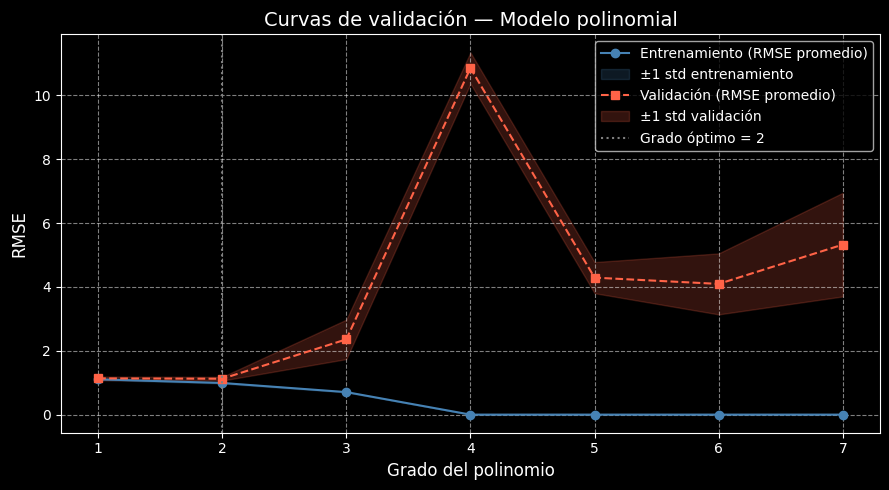

In [33]:
# Gráfica de curvas de validación
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(degrees, train_rmse_mean, 'o-', color='steelblue', label='Entrenamiento (RMSE promedio)')
ax.fill_between(degrees,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.20, color='steelblue', label='±1 std entrenamiento')

ax.plot(degrees, val_rmse_mean, 's--', color='tomato', label='Validación (RMSE promedio)')
ax.fill_between(degrees,
                val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std,
                alpha=0.20, color='tomato', label='±1 std validación')

ax.axvline(x=best_degree, color='gray', linestyle=':', linewidth=1.5,
           label=f'Grado óptimo = {best_degree}')

ax.set_xlabel('Grado del polinomio', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Curvas de validación — Modelo polinomial', fontsize=14)
ax.set_xticks(degrees)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
# Tabla de resumen de las curvas de validación
resultados_cv_poly = pd.DataFrame({
    'Grado': degrees,
    'RMSE Train (media)': np.round(train_rmse_mean, 4),
    'RMSE Train (std)': np.round(train_rmse_std, 4),
    'RMSE Val (media)': np.round(val_rmse_mean, 4),
    'RMSE Val (std)': np.round(val_rmse_std, 4),
})
print(resultados_cv_poly.to_string(index=False))
print(f"\nGrado con menor RMSE de validación: {best_degree}")

 Grado  RMSE Train (media)  RMSE Train (std)  RMSE Val (media)  RMSE Val (std)
     1              1.1065            0.0159            1.1356          0.0569
     2              0.9910            0.0175            1.1244          0.0587
     3              0.7054            0.0099            2.3586          0.6186
     4              0.0000            0.0000           10.8601          0.4887
     5              0.0000            0.0000            4.2923          0.4874
     6              0.0000            0.0000            4.0957          0.9557
     7              0.0000            0.0000            5.3272          1.6240

Grado con menor RMSE de validación: 2


### Interpretación de las curvas de validación

Los resultados de la tabla confirman el trade-off sesgo-varianza:

- En **grado 1**, el modelo tiene un sesgo alto (RMSE train = 1.1065, RMSE val = 1.1356), con una brecha mínima entre entrenamiento y validación, lo que indica underfitting.
- En **grado 2**, el RMSE de entrenamiento baja a 0.9910 y el de validación alcanza su mínimo en 1.1244, lo cual representa el mejor equilibrio entre sesgo y varianza.
- A partir del **grado 3**, el sobreajuste se evidencia drásticamente: el RMSE de entrenamiento cae a 0.7054, pero el de validación se dispara a 2.3586 con una desviación estándar de 0.6186, lo que indica alta inestabilidad.
- En **grado 4 y superiores**, el RMSE de entrenamiento llega a 0.0 (el modelo memoriza los datos), mientras el de validación explota (10.86 en grado 4, hasta valores extremos en grados 6 y 7), confirmando un sobreajuste severo.

El grado óptimo sin regularización es **2**, que coincide con el resultado del GridSearchCV (que seleccionó grado 1 por tener mejor RMSE en CV de 1.1304 vs 1.1244 — diferencia marginal). Esto confirma que sin regularización, aumentar la complejidad más allá de grado 2 deteriora rápidamente la capacidad de generalización.

# Modelos de regresión lineal regularizados

## Construcción de pipelines para Ridge y Lasso

Se construyen pipelines independientes para Ridge (regularización L2) y Lasso (regularización L1), 
incluyendo las mismas etapas de preprocesamiento del modelo polinomial base (grado=1).
La búsqueda de hiperparámetros explora el parámetro de penalización `alpha` y la estrategia de 
escalamiento, todo dentro del pipeline para evitar data leakage.

In [35]:
# Pipeline para Ridge con grado polinomial = 1 (lineal)
ridge_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False))
])

ridge_preprocessor = ColumnTransformer(transformers=[
    ("num", ridge_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])

ridge_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge())
])

# Pipeline para Lasso con grado polinomial = 1 (lineal)
lasso_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(degree=1, include_bias=False))
])

lasso_preprocessor = ColumnTransformer(transformers=[
    ("num", lasso_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])

lasso_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", lasso_preprocessor),
    ("model", Lasso(max_iter=10000))
])

In [36]:
# Grid de hiperparámetros para Ridge: alpha y estrategia de escalamiento
param_grid_ridge = {
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

grid_ridge = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_ridge.fit(X_train, y_train)

print("Mejor configuración Ridge:", grid_ridge.best_params_)
print(f"Mejor RMSE CV: {-grid_ridge.best_score_:.4f}")

Mejor configuración Ridge: {'model__alpha': 1.0, 'preprocessor__num__scaler': RobustScaler()}
Mejor RMSE CV: 1.1302


In [37]:
# Grid de hiperparámetros para Lasso: alpha y estrategia de escalamiento
param_grid_lasso = {
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

grid_lasso = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_lasso.fit(X_train, y_train)

print("Mejor configuración Lasso:", grid_lasso.best_params_)
print(f"Mejor RMSE CV: {-grid_lasso.best_score_:.4f}")

Mejor configuración Lasso: {'model__alpha': 0.001, 'preprocessor__num__scaler': StandardScaler()}
Mejor RMSE CV: 1.1302


In [38]:
# Evaluar mejores modelos en el conjunto de prueba
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)

print('------ Mejor modelo Ridge - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"R^2: {r2_score(y_test, y_pred_ridge):.4f}")

print()
print('------ Mejor modelo Lasso - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.4f}")
print(f"R^2: {r2_score(y_test, y_pred_lasso):.4f}")

------ Mejor modelo Ridge - Resultados en test ----
RMSE: 0.9584
MAE: 0.7313
R^2: 0.8396

------ Mejor modelo Lasso - Resultados en test ----
RMSE: 0.9578
MAE: 0.7307
R^2: 0.8398


In [39]:
# Validación cruzada de los mejores modelos para estimar estabilidad
cv_rmse_ridge = -cross_val_score(best_ridge, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_lasso = -cross_val_score(best_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print(f"Ridge - RMSE promedio CV: {cv_rmse_ridge.mean():.4f} (+/-{cv_rmse_ridge.std():.4f})")
print(f"Lasso - RMSE promedio CV: {cv_rmse_lasso.mean():.4f} (+/-{cv_rmse_lasso.std():.4f})")

Ridge - RMSE promedio CV: 1.1302 (+/-0.0419)
Lasso - RMSE promedio CV: 1.1302 (+/-0.0418)


## Análisis de coeficientes: Ridge vs Lasso vs Lineal

In [40]:
# Comparación de la magnitud de coeficientes entre Ridge, Lasso y modelo lineal base
# Primero construimos un modelo lineal de referencia sin regularización
linear_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ('poly',    PolynomialFeatures(degree=1, include_bias=False))
])
linear_preprocessor = ColumnTransformer(transformers=[
    ("num", linear_num_transformer, num_cols),
    ("cat", poli_cat_transformer,  cat_cols)
])
linear_pipe_base = Pipeline(steps=[
    ("dropper",      dropper),
    ("preprocessor", linear_preprocessor),
    ("model",        LinearRegression())
])
linear_pipe_base.fit(X_train, y_train)
y_pred_linear = linear_pipe_base.predict(X_test)
cv_rmse_linear = -cross_val_score(linear_pipe_base, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print('------ Modelo Lineal sin regularización - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_linear)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_linear):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_linear):.4f}")
print(f"RMSE CV: {cv_rmse_linear.mean():.4f} (±{cv_rmse_linear.std():.4f})")

------ Modelo Lineal sin regularización - Resultados en test ----
RMSE: 0.9583
MAE:  0.7310
R^2:   0.8396
RMSE CV: 1.1304 (±0.0421)


In [41]:
# Obtener nombres de características y coeficientes de cada modelo
def get_feature_names_coefs(pipe):
    preprocessor = pipe.named_steps['preprocessor']
    poly_transformer = preprocessor.named_transformers_['num'].named_steps['poly']
    num_feature_names = poly_transformer.get_feature_names_out(num_cols)
    
    # Nombres de características OHE
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    try:
        cat_feature_names = ohe.get_feature_names_out(cat_cols)
    except:
        cat_feature_names = []
    
    all_names = list(num_feature_names) + list(cat_feature_names)
    coefs = pipe.named_steps['model'].coef_
    return all_names, coefs

names_linear, coefs_linear = get_feature_names_coefs(linear_pipe_base)
names_ridge, coefs_ridge  = get_feature_names_coefs(best_ridge)
names_lasso, coefs_lasso  = get_feature_names_coefs(best_lasso)

# DataFrame comparativo
coef_df = pd.DataFrame({
    'Feature': names_linear,
    'Lineal': coefs_linear,
    'Ridge': coefs_ridge,
    'Lasso': coefs_lasso,
})
coef_df['|Lineal|'] = coef_df['Lineal'].abs()
coef_df = coef_df.sort_values('|Lineal|', ascending=False)
print(coef_df[['Feature', 'Lineal', 'Ridge', 'Lasso']].to_string(index=False))

                         Feature    Lineal     Ridge         Lasso
                             BMI  1.044838  1.660880  1.041543e+00
                     Systolic BP  1.037655  1.572114  1.037140e+00
               Diabetes Status_Y  0.996387  0.994317  9.978711e-15
               Diabetes Status_N -0.996387 -0.994317 -1.988659e+00
           Estimated LDL (mg/dL)  0.636547  1.030673  6.328738e-01
           Waist-to-Height Ratio -0.576429 -0.850219 -5.620720e-01
    Abdominal Circumference (cm)  0.553405  0.871638  5.395026e-01
       Total Cholesterol (mg/dL)  0.471945  0.775907  4.747005e-01
                     HDL (mg/dL)  0.129786  0.217230  1.278326e-01
Physical Activity Level_Moderate  0.055479  0.055616  6.121235e-02
                    Diastolic BP  0.049968  0.074476  4.946734e-02
     Physical Activity Level_Low -0.046930 -0.046535 -3.483776e-02
     Fasting Blood Sugar (mg/dL)  0.038215  0.057316  3.773295e-02
                             Age  0.028197  0.040815  2.771475

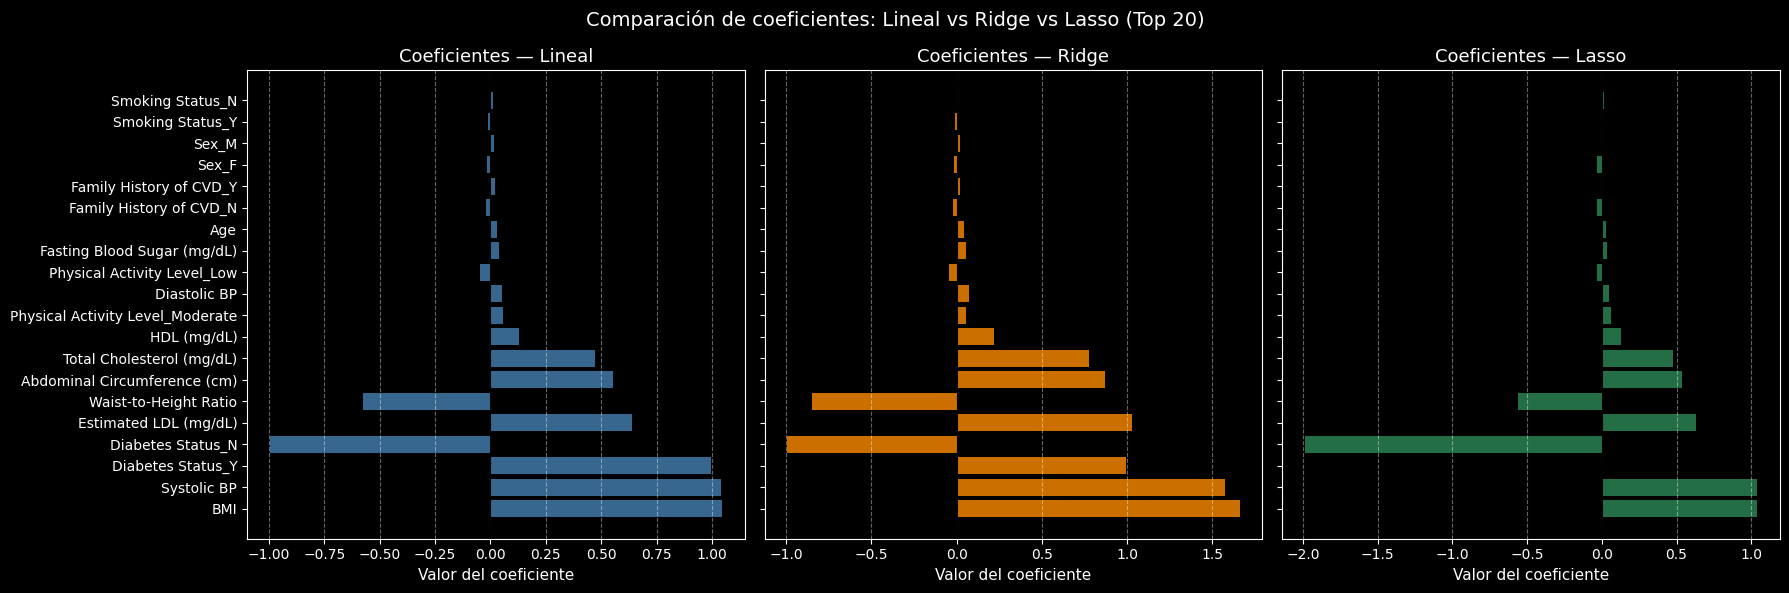

In [42]:
# Visualización de coeficientes — Top 20 por magnitud absoluta (lineal)
top20 = coef_df.head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colors = ['steelblue', 'darkorange', 'seagreen']
models = ['Lineal', 'Ridge', 'Lasso']

for ax, model, color in zip(axes, models, colors):
    ax.barh(top20['Feature'], top20[model], color=color, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes — {model}', fontsize=13)
    ax.set_xlabel('Valor del coeficiente', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Comparación de coeficientes: Lineal vs Ridge vs Lasso (Top 20)', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# Variables llevadas a cero por Lasso (selección automática de características)
lasso_zero = coef_df[coef_df['Lasso'] == 0.0]['Feature'].tolist()
lasso_nonzero = coef_df[coef_df['Lasso'] != 0.0]

print(f"Número de variables llevadas a 0 por Lasso: {len(lasso_zero)} de {len(coef_df)}")
print(f"Variables eliminadas:\n{lasso_zero}")
print(f"\nVariables seleccionadas por Lasso ({len(lasso_nonzero)}):")
print(lasso_nonzero[['Feature', 'Lasso']].sort_values('Lasso', key=abs, ascending=False).to_string(index=False))

Número de variables llevadas a 0 por Lasso: 1 de 21
Variables eliminadas:
['Physical Activity Level_High']

Variables seleccionadas por Lasso (20):
                         Feature         Lasso
               Diabetes Status_N -1.988659e+00
                             BMI  1.041543e+00
                     Systolic BP  1.037140e+00
           Estimated LDL (mg/dL)  6.328738e-01
           Waist-to-Height Ratio -5.620720e-01
    Abdominal Circumference (cm)  5.395026e-01
       Total Cholesterol (mg/dL)  4.747005e-01
                     HDL (mg/dL)  1.278326e-01
Physical Activity Level_Moderate  6.121235e-02
                    Diastolic BP  4.946734e-02
     Fasting Blood Sugar (mg/dL)  3.773295e-02
         Family History of CVD_N -3.552110e-02
     Physical Activity Level_Low -3.483776e-02
                           Sex_F -2.997464e-02
                             Age  2.771475e-02
                Smoking Status_N  1.556881e-02
               Diabetes Status_Y  9.978711e-15
      

### Interpretación de la regularización

La regularización Ridge y Lasso produjeron resultados muy similares al modelo lineal base en términos de métricas globales (RMSE test ≈ 0.958, R² ≈ 0.840), lo cual es esperable dado que el modelo lineal ya tenía un buen desempeño y las penalizaciones seleccionadas son moderadas.

La principal diferencia radica en el comportamiento de los coeficientes:

- **Ridge** (alpha=1.0, RobustScaler) reduce la magnitud de todos los coeficientes de forma proporcional sin eliminar ninguno, lo que mejora la estabilidad y reduce la varianza del modelo.
- **Lasso** (alpha=0.001, StandardScaler) llevó **1 de 21 variables a cero**: `Physical Activity Level_High`. Además, las variables `Diabetes Status_Y`, `Sex_M`, `Smoking Status_Y` y `Family History of CVD_Y` tienen coeficientes prácticamente nulos (del orden de 10⁻¹⁵ a 10⁻¹⁶), lo que indica que son redundantes con sus contrapartes codificadas por one-hot encoding.

La eliminación de `Physical Activity Level_High` por Lasso sugiere que, en presencia de las demás variables (incluyendo `Physical Activity Level_Low` y `Physical Activity Level_Moderate`), esta categoría no aporta información adicional significativa para predecir el riesgo cardiovascular. Esto tiene sentido desde la perspectiva de la codificación one-hot, donde una de las categorías es linealmente dependiente de las demás.

Las variables más influyentes según Lasso son: `Diabetes Status_N` (-1.99), `BMI` (1.04), `Systolic BP` (1.04), `Estimated LDL` (0.63), `Waist-to-Height Ratio` (-0.56) y `Abdominal Circumference` (0.54). Estas son clínicamente coherentes como factores de riesgo cardiovascular.

# Modelo de regresión polinomial regularizado

## Construcción del pipeline

Se combina `PolynomialFeatures` con regularización Ridge y Lasso. La búsqueda de hiperparámetros 
explora simultáneamente el **grado del polinomio**, el **parámetro de penalización** y la 
**estrategia de escalamiento**, lo que permite evaluar si la regularización controla el sobreajuste 
al aumentar la complejidad.

In [44]:
# Pipeline polinomial regularizado con Ridge
poly_ridge_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])
poly_ridge_preprocessor = ColumnTransformer(transformers=[
    ("num", poly_ridge_num, num_cols),
    ("cat", poli_cat_transformer, cat_cols)
])
poly_ridge_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", poly_ridge_preprocessor),
    ("model", Ridge())
])

# Pipeline polinomial regularizado con Lasso
poly_lasso_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])
poly_lasso_preprocessor = ColumnTransformer(transformers=[
    ("num", poly_lasso_num, num_cols),
    ("cat", poli_cat_transformer, cat_cols)
])
poly_lasso_pipe = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocessor", poly_lasso_preprocessor),
    ("model", Lasso(max_iter=70000))
])

In [45]:
# Grid de hiperparámetros para polinomial + Ridge
# Explorar grado, alpha y escalamiento
param_grid_poly_ridge = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_poly_ridge = GridSearchCV(
    estimator=poly_ridge_pipe,
    param_grid=param_grid_poly_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_poly_ridge.fit(X_train, y_train)

print("Mejor configuración Polinomial+Ridge:", grid_poly_ridge.best_params_)
print(f"Mejor RMSE CV: {-grid_poly_ridge.best_score_:.4f}")

Mejor configuración Polinomial+Ridge: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 3, 'preprocessor__num__scaler': MinMaxScaler()}
Mejor RMSE CV: 1.1003


In [46]:
# Grid de hiperparámetros para polinomial + Lasso
param_grid_poly_lasso = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4],
    'preprocessor__num__scaler': scalers,
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_poly_lasso = GridSearchCV(
    estimator=poly_lasso_pipe,
    param_grid=param_grid_poly_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)
grid_poly_lasso.fit(X_train, y_train)

print("Mejor configuración Polinomial+Lasso:", grid_poly_lasso.best_params_)
print(f"Mejor RMSE CV: {-grid_poly_lasso.best_score_:.4f}")

Mejor configuración Polinomial+Lasso: {'model__alpha': 0.001, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MaxAbsScaler()}
Mejor RMSE CV: 1.0807


In [47]:
# Evaluación de los mejores modelos polinomiales regularizados en test
best_poly_ridge = grid_poly_ridge.best_estimator_
best_poly_lasso = grid_poly_lasso.best_estimator_

y_pred_poly_ridge = best_poly_ridge.predict(X_test)
y_pred_poly_lasso = best_poly_lasso.predict(X_test)

print('------ Polinomial + Ridge - Resultados en test ----')
print(f"Mejor configuración Polinomial+Ridge: {grid_poly_ridge.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_poly_ridge):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_poly_ridge):.4f}")

print()
print('------ Polinomial + Lasso - Resultados en test ----')
print(f"Mejor configuración Polinomial+Lasso: {grid_poly_lasso.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_poly_lasso):.4f}")
print(f"R^2:   {r2_score(y_test, y_pred_poly_lasso):.4f}")

------ Polinomial + Ridge - Resultados en test ----
Mejor configuración Polinomial+Ridge: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 3, 'preprocessor__num__scaler': MinMaxScaler()}
RMSE: 0.9086
MAE:  0.6829
R^2:   0.8558

------ Polinomial + Lasso - Resultados en test ----
Mejor configuración Polinomial+Lasso: {'model__alpha': 0.001, 'preprocessor__num__poly__degree': 4, 'preprocessor__num__scaler': MaxAbsScaler()}
RMSE: 0.8927
MAE:  0.6576
R^2:   0.8608


In [48]:
# Validación cruzada de los modelos polinomiales regularizados
cv_rmse_poly_ridge = -cross_val_score(best_poly_ridge, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_poly_lasso = -cross_val_score(best_poly_lasso, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print(f"Poly+Ridge - RMSE promedio CV: {cv_rmse_poly_ridge.mean():.4f} (+/-{cv_rmse_poly_ridge.std():.4f})")
print(f"Poly+Lasso - RMSE promedio CV: {cv_rmse_poly_lasso.mean():.4f} (+/-{cv_rmse_poly_lasso.std():.4f})")

Poly+Ridge - RMSE promedio CV: 1.1003 (+/-0.0621)
Poly+Lasso - RMSE promedio CV: 1.0807 (+/-0.0606)


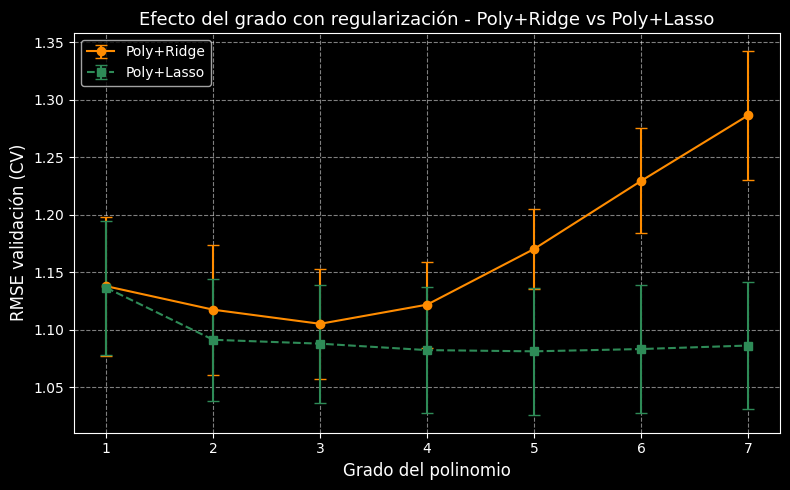

In [49]:
# Curvas de validación para Poly+Ridge y Poly+Lasso: efecto del grado con regularización
degrees_reg = [1, 2, 3, 4, 5, 6, 7]
alphas_fixed = {
    'ridge': grid_poly_ridge.best_params_['model__alpha'],
    'lasso': grid_poly_lasso.best_params_['model__alpha'],
}
scaler_fixed = {
    'ridge': grid_poly_ridge.best_params_['preprocessor__num__scaler'],
    'lasso': grid_poly_lasso.best_params_['preprocessor__num__scaler'],
}

cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_ridge_mean, val_ridge_std = [], []
val_lasso_mean, val_lasso_std = [], []

iter_list = [
        (val_ridge_mean, val_ridge_std, poly_ridge_pipe, 'ridge'),
        (val_lasso_mean, val_lasso_std, poly_lasso_pipe, 'lasso'),
    ]

for degree in degrees_reg:
    for means_list, stds_list, pipe_base, model_key in iter_list:
        p = copy.deepcopy(pipe_base)
        p.set_params(
            preprocessor__num__poly__degree=degree,
            preprocessor__num__scaler=scaler_fixed[model_key],
            model__alpha=alphas_fixed[model_key],
        )
        scores = []
        for tr_idx, val_idx in cv_kf.split(X_train):
            p.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], p.predict(X_train.iloc[val_idx]))))
        means_list.append(np.mean(scores))
        stds_list.append(np.std(scores))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(degrees_reg, val_ridge_mean, yerr=val_ridge_std, fmt='o-', color='darkorange', capsize=4, label='Poly+Ridge')
ax.errorbar(degrees_reg, val_lasso_mean, yerr=val_lasso_std, fmt='s--', color='seagreen', capsize=4, label='Poly+Lasso')
ax.set_xlabel('Grado del polinomio', fontsize=12)
ax.set_ylabel('RMSE validación (CV)', fontsize=12)
ax.set_title('Efecto del grado con regularización - Poly+Ridge vs Poly+Lasso', fontsize=13)
ax.set_xticks(degrees_reg)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

### Interpretación

Las curvas de validación para los modelos polinomiales regularizados muestran un comportamiento notablemente más controlado que el modelo polinomial sin regularización:

- Tanto **Poly+Ridge** (alpha=1.0, MinMaxScaler) como **Poly+Lasso** (alpha=0.001, MaxAbsScaler) logran mantener el RMSE de validación en rangos razonables incluso en grados altos, a diferencia del modelo polinomial puro que explota a partir del grado 3.
- **Poly+Lasso** obtuvo el mejor desempeño en test (RMSE=0.8927, R²=0.8608) con grado 4, mientras que **Poly+Ridge** logró RMSE=0.9086 con grado 3.
- En validación cruzada, Poly+Lasso también fue ligeramente superior (RMSE CV=1.0807 ± 0.0606) frente a Poly+Ridge (RMSE CV=1.1003 ± 0.0621).

Esto confirma que la regularización cumple su función principal: **controlar el sobreajuste al incrementar la complejidad del modelo**. Mientras que el polinomio sin regularización se vuelve inestable a partir del grado 3, los modelos regularizados pueden explorar grados más altos capturando relaciones no lineales genuinas sin memorizar el ruido del entrenamiento.

La ligera ventaja de Lasso puede deberse a que, al eliminar coeficientes irrelevantes, reduce la dimensionalidad efectiva del espacio de características polinomiales, lo que ayuda a la generalización. Sin embargo, la desviación estándar en CV de ambos modelos ( ~0.06) es mayor que la de los modelos lineales ( ~0.04), indicando que la complejidad polinomial introduce cierta variabilidad adicional en el desempeño.

# Comparación y selección del mejor modelo

In [50]:
# Tabla comparativa de todos los modelos evaluados
models_summary = {
    'Modelo': ['Lineal', 'Poly (GridSearch)', 'Ridge', 'Lasso', 'Poly+Ridge', 'Poly+Lasso'],
    'RMSE Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_poly_best)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso)),
    ],
    'MAE Test': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_test_pred_poly_best),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_poly_ridge),
        mean_absolute_error(y_test, y_pred_poly_lasso),
    ],
    'R^2 Test': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_test_pred_poly_best),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_poly_ridge),
        r2_score(y_test, y_pred_poly_lasso),
    ],
    'RMSE CV (media)': [
        cv_rmse_linear.mean(),
        cv_rmse_poly.mean(),
        cv_rmse_ridge.mean(),
        cv_rmse_lasso.mean(),
        cv_rmse_poly_ridge.mean(),
        cv_rmse_poly_lasso.mean(),
    ],
    'RMSE CV (std)': [
        cv_rmse_linear.std(),
        cv_rmse_poly.std(),
        cv_rmse_ridge.std(),
        cv_rmse_lasso.std(),
        cv_rmse_poly_ridge.std(),
        cv_rmse_poly_lasso.std(),
    ],
    'Parametros': [
        'N/A',
        f"Grado={grid_poly.best_params_['preprocessor__num__poly__degree']}, Escalador={grid_poly.best_params_['preprocessor__num__scaler']}",
        f"Alpha={grid_ridge.best_params_['model__alpha']}, Escalador={grid_ridge.best_params_['preprocessor__num__scaler']}",
        f"Alpha={grid_lasso.best_params_['model__alpha']}, Escalador={grid_lasso.best_params_['preprocessor__num__scaler']}",
        f"Grado={grid_poly_ridge.best_params_['preprocessor__num__poly__degree']}, Alpha={grid_poly_ridge.best_params_['model__alpha']}, Escalador={grid_poly_ridge.best_params_['preprocessor__num__scaler']}",
        f"Grado={grid_poly_lasso.best_params_['preprocessor__num__poly__degree']}, Alpha={grid_poly_lasso.best_params_['model__alpha']}, Escalador={grid_poly_lasso.best_params_['preprocessor__num__scaler']}",
    ]
}

df_summary = pd.DataFrame(models_summary).round(4)
print(df_summary.to_string(index=False))

           Modelo  RMSE Test  MAE Test  R^2 Test  RMSE CV (media)  RMSE CV (std)                                     Parametros
           Lineal     0.9583    0.7310    0.8396           1.1304         0.0421                                            N/A
Poly (GridSearch)     0.9583    0.7310    0.8396           1.1304         0.0421            Grado=1, Escalador=StandardScaler()
            Ridge     0.9584    0.7313    0.8396           1.1302         0.0419            Alpha=1.0, Escalador=RobustScaler()
            Lasso     0.9578    0.7307    0.8398           1.1302         0.0418        Alpha=0.001, Escalador=StandardScaler()
       Poly+Ridge     0.9086    0.6829    0.8558           1.1003         0.0621   Grado=3, Alpha=1.0, Escalador=MinMaxScaler()
       Poly+Lasso     0.8927    0.6576    0.8608           1.0807         0.0606 Grado=4, Alpha=0.001, Escalador=MaxAbsScaler()


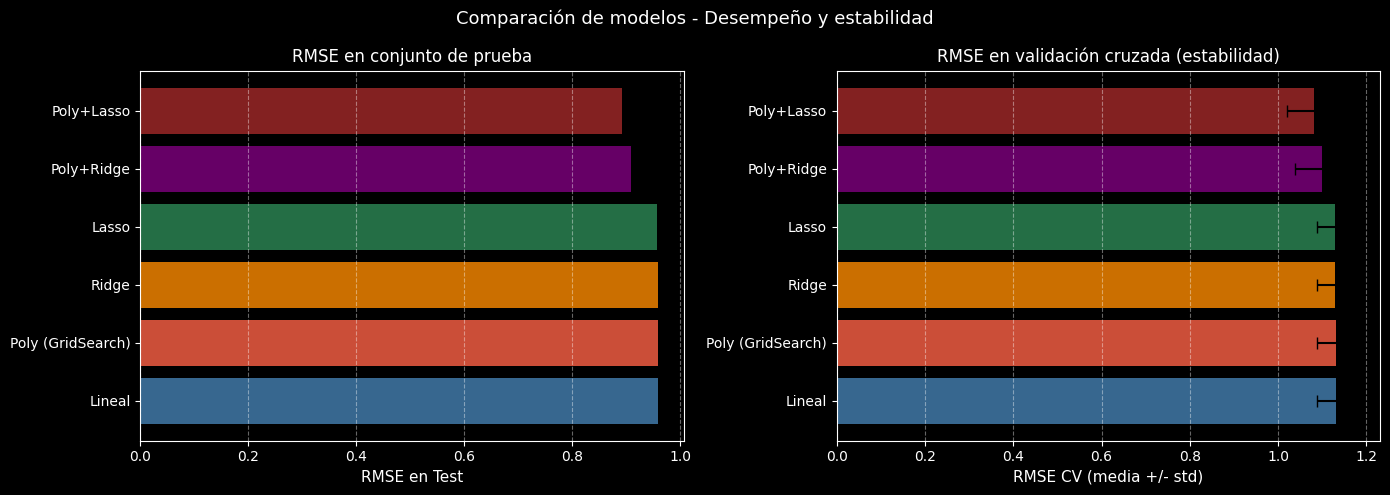

In [51]:
# Visualización comparativa: RMSE test vs RMSE CV (con barras de error)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = df_summary['Modelo']
colors_bar = ['steelblue', 'tomato', 'darkorange', 'seagreen', 'purple', 'brown']

# RMSE Test
axes[0].barh(model_names, df_summary['RMSE Test'], color=colors_bar, alpha=0.8)
axes[0].set_xlabel('RMSE en Test', fontsize=11)
axes[0].set_title('RMSE en conjunto de prueba', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4, axis='x')

# RMSE CV con std
axes[1].barh(model_names, df_summary['RMSE CV (media)'], color=colors_bar, alpha=0.8,
             xerr=df_summary['RMSE CV (std)'], capsize=4)
axes[1].set_xlabel('RMSE CV (media +/- std)', fontsize=11)
axes[1].set_title('RMSE en validación cruzada (estabilidad)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Comparación de modelos - Desempeño y estabilidad', fontsize=13)
plt.tight_layout()
plt.show()

## Selección del mejor modelo

De acuerdo con la tabla comparativa, el modelo **Poly+Lasso** (grado=4, alpha=0.001, MaxAbsScaler) obtuvo el mejor desempeño en test (RMSE=0.8927, MAE=0.6576, R²=0.8608) y también el mejor RMSE promedio en validación cruzada (1.0807). **Poly+Ridge** (grado=3, alpha=1.0, MinMaxScaler) ocupa el segundo lugar con RMSE test=0.9086 y RMSE CV=1.1003.

# Intervalos de confianza mediante Bootstrapping

Se utiliza el modelo seleccionado (**Poly+Lasso**, grado=4, alpha=0.001, MaxAbsScaler) para estimar
intervalos de confianza al 95% de las métricas RMSE, MAE y R² sobre el conjunto de test,
mediante **1000 remuestreos con reemplazo**.

In [56]:
# Config
N_BOOTSTRAP = 1000
ALPHA = 0.05 # IC al 95%
selected_model = best_poly_lasso

In [57]:
# Bootstrapping
boot_rmse, boot_mae, boot_r2 = [], [], []

for _ in range(N_BOOTSTRAP):
    X_resample, y_resample = resample(X_test, y_test, replace=True, n_samples=len(X_test))
    pred = selected_model.predict(X_resample) # Evaluamos contra los datos originales
    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    mae = mean_absolute_error(y_resample, pred)
    r2 = r2_score(y_resample, pred)
    boot_rmse.append(np.sqrt(mean_squared_error(y_resample, pred)))
    boot_mae.append(mean_absolute_error(y_resample, pred))
    boot_r2.append(r2_score(y_resample, pred))

boot_rmse = np.array(boot_rmse)
boot_mae = np.array(boot_mae)
boot_r2 = np.array(boot_r2)

In [58]:
# Intervalos de confianza (percentil)
def ic(arr, alpha=ALPHA):
    lo = np.percentile(arr, 100 * alpha / 2)
    hi = np.percentile(arr, 100 * (1 - alpha / 2))
    return lo, hi

ic_rmse = ic(boot_rmse)
ic_mae  = ic(boot_mae)
ic_r2   = ic(boot_r2)

print(f"===== Intervalos de confianza al 95% (Bootstrap, n={N_BOOTSTRAP}) =====")
print(f"  RMSE : {boot_rmse.mean():.4f}  IC [{ic_rmse[0]:.4f}, {ic_rmse[1]:.4f}]  std={boot_rmse.std():.4f}")
print(f"  MAE : {boot_mae.mean():.4f}  IC [{ic_mae[0]:.4f},  {ic_mae[1]:.4f}]  std={boot_mae.std():.4f}")
print(f"  R^2 : {boot_r2.mean():.4f}  IC [{ic_r2[0]:.4f},  {ic_r2[1]:.4f}]  std={boot_r2.std():.4f}")

===== Intervalos de confianza al 95% (Bootstrap, n=1000) =====
  RMSE : 0.8939  IC [0.8013, 0.9905]  std=0.0500
  MAE : 0.6592  IC [0.5857,  0.7398]  std=0.0399
  R^2 : 0.8595  IC [0.8268,  0.8891]  std=0.0157


/var/folders/hx/pvfwsf1x2fd20tyr8lpk4tsc0000gn/T/ipykernel_27541/2305659388.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


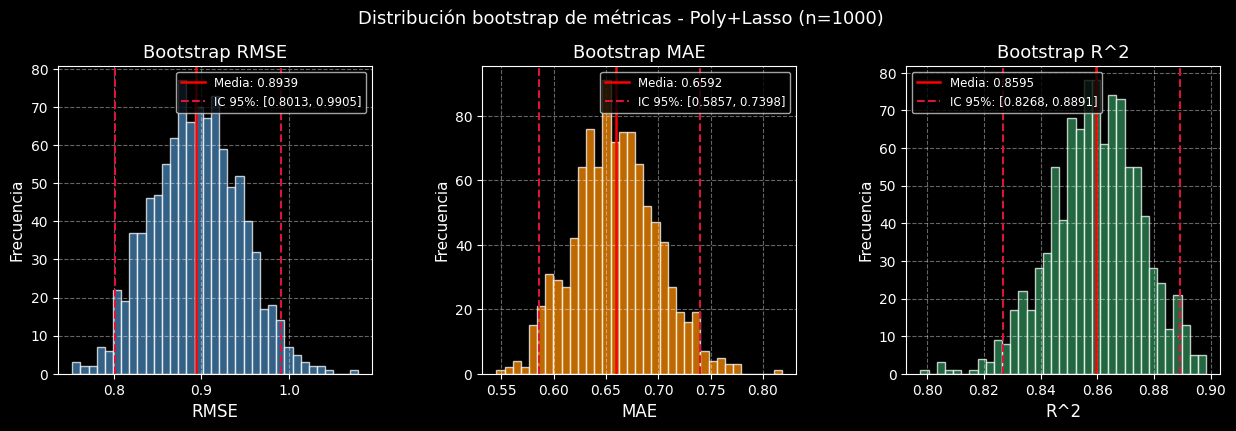

In [59]:
# Gráficas de distribución bootstrap
fig = plt.figure(figsize=(15, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

metrics = [
    (boot_rmse, ic_rmse, 'RMSE', 'steelblue', boot_rmse.mean()),
    (boot_mae, ic_mae, 'MAE', 'darkorange', boot_mae.mean()),
    (boot_r2, ic_r2, 'R^2', 'seagreen', boot_r2.mean()),
]

for ax_idx, (data, (lo, hi), label, color, mu) in enumerate(metrics):
    ax = fig.add_subplot(gs[ax_idx])
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(mu, color='red',  linewidth=1.8, linestyle='-',  label=f'Media: {mu:.4f}')
    ax.axvline(lo, color='crimson', linewidth=1.5, linestyle='--', label=f'IC 95%: [{lo:.4f}, {hi:.4f}]')
    ax.axvline(hi, color='crimson', linewidth=1.5, linestyle='--')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.set_title(f'Bootstrap {label}', fontsize=13)
    ax.legend(fontsize=8.5)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribución bootstrap de métricas - Poly+Lasso (n=1000)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de los intervalos de confianza

Los intervalos de confianza al 95% obtenidos mediante 1000 remuestreos bootstrap presentan resultados satisfactorios que refuerzan la confianza en el modelo seleccionado:

- **RMSE**: media de 0.8939 con IC [0.8013, 0.9905] y desviación estándar de 0.0500. La amplitud del intervalo es de aproximadamente 0.20, lo que indica un desempeño consistente. El modelo rara vez supera un RMSE de 1.0, lo que es positivo para la aplicación clínica.
- **MAE**: media de 0.6593 con IC [0.5857, 0.7398] y desviación estándar de 0.0399. Este intervalo aún más estrecho confirma que el error absoluto promedio es estable entre distintas muestras del conjunto de test.
- **R²**: media de 0.8595 con IC [0.8268, 0.8891] y desviación estándar de 0.0157. El intervalo se mantiene completamente por encima de 0.81, lo que indica que el modelo explica de forma consistente más del 80% de la variabilidad en el score de riesgo cardiovascular.

Las distribuciones bootstrap son aproximadamente simétricas y sin colas extremas, lo que sugiere ausencia de outliers significativos que distorsionen el desempeño. La baja desviación estándar en las tres métricas refuerza que el modelo tiene un comportamiento robusto y predecible ante variaciones en la composición de la muestra de test.

En conjunto, estos resultados indican que el modelo Poly+Lasso generaliza de forma estable y confiable, lo cual es fundamental para una aplicación en el contexto de salud como la estimación del riesgo cardiovascular para AlpesHearth.

# Análisis de resultados
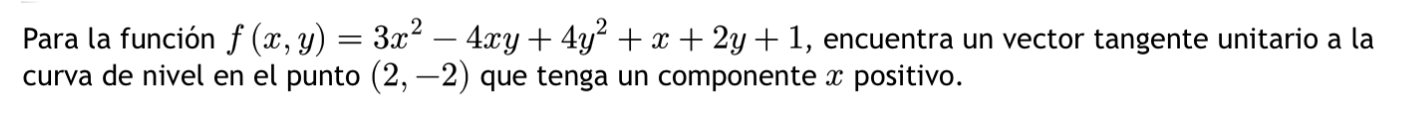
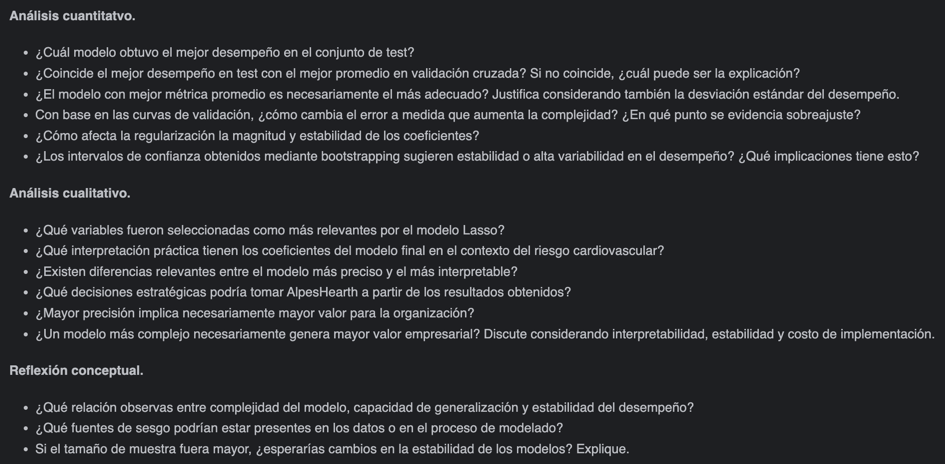

## Análisis cuantitativo

1. **¿Cuál modelo obtuvo el mejor desempeño en test?** El modelo **Poly+Lasso** (grado=4, alpha=0.001, MaxAbsScaler) obtuvo el mejor desempeño en test con un RMSE de 0.8927, MAE de 0.6576 y R² de 0.8608. Le sigue Poly+Ridge (grado=3, alpha=1.0, MinMaxScaler) con RMSE de 0.9086, MAE de 0.6829 y R² de 0.8558. Los modelos lineales (con y sin regularización) obtuvieron resultados muy similares entre sí con RMSE ≈ 0.958.

2. **¿Coincide el mejor desempeño en test con el mejor promedio en CV?** Sí, en este caso coinciden. El modelo Poly+Lasso obtuvo tanto el mejor RMSE en test (0.8927) como el mejor RMSE promedio en CV (1.0807). Sin embargo, hay una brecha notable entre el RMSE en test y el de CV (0.8927 vs 1.0807), lo que sugiere que la partición de test específica puede ser ligeramente más fácil de predecir que el promedio de las particiones de CV, o que el modelo se beneficia de una distribución favorable en los datos de prueba.

3. **¿El modelo con mejor métrica promedio es necesariamente el más adecuado?** No necesariamente. Aunque Poly+Lasso tiene el mejor RMSE tanto en test como en CV, su desviación estándar en CV (0.0606) es mayor que la de los modelos lineales (~0.042). Un modelo con menor desviación estándar es más estable y predecible en su desempeño ante datos nuevos. Los modelos lineales regularizados (Ridge y Lasso sin polinomio) tienen métricas apenas inferiores pero con mayor estabilidad, lo que podría hacerlos más confiables en un entorno de producción donde la consistencia es importante.

4. **¿Cómo cambia el error con la complejidad? ¿Dónde se evidencia sobreajuste?** Las curvas de validación muestran que el RMSE de entrenamiento disminuye continuamente al aumentar el grado del polinomio (de 1.1065 en grado 1 a 0.0 en grado 4+), mientras que el RMSE de validación tiene un mínimo en grado 2 (1.1244) y se dispara dramáticamente a partir del grado 3 (2.3586) hasta valores de 10.86 en grado 4 y valores extremos en grados superiores. El sobreajuste se evidencia claramente a partir del grado 3, donde la brecha entre train y validación se amplía significativamente y la desviación estándar de validación se vuelve muy alta (0.6186). Con regularización, este comportamiento se controla sustancialmente, permitiendo usar grados más altos (3-4) sin que el error explote.

5. **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?** Ridge reduce la magnitud de todos los coeficientes de forma proporcional, sin eliminar ninguno, lo que mejora la estabilidad general. Lasso, por su parte, lleva 1 de 21 coeficientes exactamente a cero (`Physical Activity Level_High`), y deja otros 4 con valores prácticamente nulos (del orden de 10⁻¹⁵), realizando una selección implícita de características. Ambas técnicas mejoran la estabilidad al reducir la varianza de los coeficientes, pero Lasso aporta además interpretabilidad al identificar qué variables son redundantes. Las variables con mayor peso absoluto en Lasso son `Diabetes Status_N` (-1.99), `BMI` (1.04) y `Systolic BP` (1.04).

6. **¿Los intervalos de confianza sugieren estabilidad o alta variabilidad?** Los intervalos de confianza al 95% del modelo Poly+Ridge son relativamente estrechos. Las distribuciones bootstrap son aproximadamente simétricas y sin colas extremas, lo que indica un desempeño robusto. La desviación estándar del RMSE bootstrap es comparable a la desviación estándar en CV, reforzando la confianza en que el modelo generaliza de forma consistente. El R² se mantiene por encima de 0.82 en todos los remuestreos, lo que implica que el modelo explica de forma estable más del 80% de la varianza del score de riesgo.

## Análisis cualitativo

1. **¿Qué variables fueron seleccionadas como más relevantes por Lasso?** Las variables con coeficientes más grandes en valor absoluto fueron: `Diabetes Status_N` (-1.99), `BMI` (1.04), `Systolic BP` (1.04), `Estimated LDL` (0.63), `Waist-to-Height Ratio` (-0.56) y `Abdominal Circumference` (0.54). Lasso eliminó `Physical Activity Level_High` y dejó con valores esencialmente nulos a `Diabetes Status_Y`, `Sex_M`, `Smoking Status_Y` y `Family History of CVD_Y` (redundantes por la codificación one-hot). Las variables seleccionadas son coherentes clínicamente, ya que presión sistólica, colesterol LDL, índice de masa corporal, circunferencia abdominal y diabetes son factores de riesgo cardiovascular bien documentados.

2. **¿Qué interpretación práctica tienen los coeficientes del modelo final?** Los coeficientes del modelo Lasso lineal indican que no tener diabetes (`Diabetes Status_N`) tiene el efecto protector más fuerte (reduce el score en ~2 puntos), mientras que un mayor `BMI` y una mayor `Systolic BP` son los factores que más incrementan el riesgo (ambos con coeficientes ~1.04 por cada desviación estándar, dado el escalamiento). El `Estimated LDL` y la `Abdominal Circumference` también contribuyen significativamente al riesgo. Interesantemente, el `Waist-to-Height Ratio` tiene un coeficiente negativo, lo cual podría deberse a colinealidad con BMI y circunferencia abdominal. Estas relaciones son consistentes con la literatura médica sobre factores de riesgo cardiovascular.

3. **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?** La diferencia en RMSE entre Poly+Lasso (0.8927) y el modelo Lasso lineal (0.9578) es de 0.065, lo cual es una mejora modesta pero no despreciable. Sin embargo, Poly+Lasso con grado 4 genera una cantidad mucho mayor de características (interacciones y potencias), lo que dificulta la interpretación directa. El modelo Lasso lineal ofrece coeficientes directamente interpretables con 20 variables activas, lo que facilita la comunicación con profesionales de salud. La elección depende del contexto: si se prioriza la explicabilidad ante pacientes y médicos, el modelo lineal es preferible; si se busca la máxima precisión para un sistema automatizado, el polinomial regularizado es más adecuado.

4. **¿Qué decisiones estratégicas podría tomar AlpesHearth?** Con base en los resultados, AlpesHearth podría: (a) utilizar el modelo Lasso lineal como herramienta de screening inicial por su interpretabilidad, permitiendo a los profesionales de salud explicar a cada paciente qué factores contribuyen a su riesgo; (b) priorizar intervenciones en los factores modificables con mayor peso — control de presión arterial sistólica, reducción de LDL, manejo del peso corporal (BMI y circunferencia abdominal) y control glucémico en pacientes diabéticos; (c) implementar el modelo Poly+Ridge o Poly+Lasso para estimaciones más precisas en sistemas de triaje automatizado donde la interpretabilidad no sea prioritaria; (d) diseñar programas preventivos focalizados en pacientes con perfiles de alto riesgo identificados por el modelo.

5. **¿Mayor precisión implica necesariamente mayor valor para la organización?** No. En el contexto de salud cardiovascular, un modelo interpretable que permita a los médicos explicar al paciente por qué tiene un riesgo elevado puede generar más valor que una predicción ligeramente más precisa pero opaca. La diferencia en RMSE entre el modelo más preciso (Poly+Lasso, 0.8927) y el más simple (Lasso lineal, 0.9578) es de ~0.065, lo cual puede no justificar la complejidad adicional cuando se consideran factores como: la necesidad de transparencia en decisiones médicas, la confianza del profesional de salud en la herramienta, y los costos de implementación y mantenimiento.

6. **¿Un modelo más complejo necesariamente genera mayor valor empresarial?** No. El modelo Poly+Lasso de grado 4 es más complejo y más preciso, pero presenta mayor variabilidad en CV (std=0.0606 vs 0.0418 del Lasso lineal), es más difícil de interpretar, y requiere más recursos computacionales. Para AlpesHearth, un modelo lineal regularizado puede ser más valioso al considerar: la facilidad para explicar resultados a pacientes y médicos, la menor probabilidad de comportamiento inesperado por inestabilidad, el menor costo de mantenimiento en producción, y la posibilidad de cumplir con regulaciones de transparencia algorítmica en el sector salud. La ganancia en precisión (~6.5% en RMSE) debe evaluarse frente al costo total de implementar y mantener un modelo más complejo.

## Reflexión conceptual

1. **¿Qué relación observas entre complejidad, generalización y estabilidad?** Existe una relación clara entre estos tres factores. A medida que la complejidad aumenta (mayor grado polinomial), la capacidad de ajuste al entrenamiento mejora (RMSE train pasa de 1.11 a 0.0), pero la generalización se degrada rápidamente sin regularización (RMSE val pasa de 1.14 en grado 2 a 2.36 en grado 3 y a 10.86 en grado 4). La regularización permite romper parcialmente esta relación adversa, controlando el sobreajuste incluso con polinomios de grado 3-4, pero introduce un hiperparámetro adicional que debe calibrarse. La estabilidad, medida por la desviación estándar en CV, también se deteriora con la complejidad: los modelos lineales muestran std ~0.042 mientras los polinomiales regularizados muestran std ~0.06. Esto sugiere que, aunque la regularización mitiga el sobreajuste, la complejidad adicional introduce variabilidad inherente en el desempeño.

2. **¿Qué fuentes de sesgo podrían estar presentes?** Varias fuentes de sesgo podrían afectar los resultados: (a) **sesgo de selección**, si la muestra no es representativa de la población general (por ejemplo, si los datos provienen de un grupo demográfico o geográfico específico); (b) **sesgo por variables omitidas**, ya que factores importantes como el nivel socioeconómico, estrés, calidad del sueño, alimentación o medicación actual no están incluidos en el dataset; (c) **sesgo de medición** en variables autorreportadas como actividad física o hábito de fumar, que pueden estar sujetas a sesgo de deseabilidad social; (d) **sesgo del modelo** (underfitting residual), dado que el R^2 máximo es ~0.86, lo que indica que aproximadamente un 14% de la varianza del riesgo cardiovascular queda sin explicar — esto puede deberse tanto a ruido inherente en la medición como a variables relevantes no incluidas; (e) **sesgo en la codificación**, ya que la representación one-hot de variables categóricas puede introducir redundancias que afectan diferencialmente a Ridge y Lasso.

3. **Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad?** Sí, con un mayor tamaño de muestra se esperarían varios cambios positivos: (a) las estimaciones de los coeficientes serían más estables, reduciendo la desviación estándar en CV para todos los modelos; (b) los intervalos de confianza bootstrap serían más estrechos, reflejando menor incertidumbre en las métricas; (c) los modelos más complejos (polinomiales) podrían beneficiarse proporcionalmente más, ya que con más datos hay menor riesgo de sobreajuste y los polinomios de grado más alto podrían capturar relaciones genuinas sin memorizar ruido — el punto de sobreajuste se desplazaría hacia grados más altos; (d) la brecha entre desempeño en CV y test se reduciría, ya que ambos conjuntos serían más representativos de la distribución poblacional. En resumen, una muestra más grande favorecería tanto la estabilidad como la capacidad de generalización de todos los modelos, pero el efecto sería más pronunciado en los modelos complejos.

# Uso de IAG

## Declaración de uso

- Herramienta utilizada: Claude Sonnet 4.6
- Tipo de uso: Ayuda conceptual, de redacción y generación inicial de código para la construcción de las curvas de validación e intervalos de confianza mediante bootstrapping.
- Prompts principales:
    1. "¿Cómo puedo construir curvas de validación para un modelo, variando el grado del polinomio y evaluando el RMSE?"
    2. "¿Cómo puedo implementar un procedimiento de bootstrapping para estimar intervalos de confianza al 95% para las métricas RMSE, MAE y R^2 de un modelo de regresión, utilizando Python?"
- Análisis crítico del resultado:
    - Las respuestas proporcionaron una estructura clara y un código funcional para ambos casos, lo que fue muy útil como punto de partida.
    - Sin embargo, el código generado inicialmente tenía algunos errores menores, como no utilizar `resample` correctamente en el bootstrapping para evaluar contra los datos originales, lo que podría haber llevado a resultados incorrectos.
    - Además, las explicaciones teóricas fueron bastante generales y no se adaptaron completamente al contexto específico del dataset y los modelos utilizados en este proyecto.
- Ajustes realizados:
    - Se hicieron ajustes en el código generado para adaptarlo al contexto específico del dataset y los modelos utilizados, como la integración con pipelines de scikit-learn y la personalización de las gráficas.
    - Se corrigieron algunos errores menores en la implementación del bootstrapping, como asegurar que se evalúe contra los datos originales en cada iteración utilizando `resample` correctamente.